# Figure 5b: H5N1 shared SNPs permutation test

June 6, 2019

Trevor suggested that I run some simulations randomly assigning polymorphic sites to random parts of the genome and then seeing how much sharing occurs when this is random. The idea here is that we have identified 9 polymorphic amino acid sites that are shared in at least 2 samples. However, we don't have any great idea about whether that is more or less sharing than we would expect by chance alone. The idea is to do the following: 

1. For each gene and individual, calculate the number of amino acid polymorphisms present in the sample. Record that. 
2. Simulate the same number of individuals and gene segments that we have, and assign them polymorphism at random sites.
3. Compute how many SNPs polymorphic sites are shared among at least 2 samples. 
4. Repeat for 10,000 simulations to generate a distribution. 
5. Compare with the actual number of observed shared sites (3 and 9). 

In [1]:
# import necessary modules
import sys, subprocess, glob, os, shutil, re, importlib, Bio, csv
from subprocess import call
from Bio import SeqIO
import numpy as np
import pandas as pd
import random
from random import randint
from collections import Counter
# import rpy2
# %load_ext rpy2.ipython

In [2]:
# # define colors 
# commercial_color = "#C15D1A"
# lbm_color = "#3C7067"

# define colors 
clust1 = "#ef476f" #bubblegumpink
clust2 = "#ffd166" #royalgold
clust2 = "#FF7518" #orange
clust4 = "#06d6a0" #blue
clust5 = "118ab2" #teal
clust6 = "073b4c" #darkblue

## Step 1: Write the simulator 

I will first write the simulator that will take as input an array of samples with polymorphic sites in their genomes and the number of simulations to perform. This will then randomly assign the sites and run the simulation. 

In [3]:
def simulate_shared_sites(polymorphisms_array, num_sites_array, num_sims):
    
    iteration_results = {"PB2":[], "PB1":[], "PA":[], "HA":[], "NP":[],"NA":[], "M1":[], "M2":[], "NS1":[], "NEP":[]}
    
    for i in range(0, num_sims):
        
        results = {"PB2":[], "PB1":[], "PA":[], "HA":[], "NP":[],"NA":[], "M1":[], "M2":[], "NS1":[], "NEP":[]}
    
        for sample in polymorphisms_array:
            for gene in polymorphisms_array[sample]:
                
                # define the number of possible sites
                num_possible_sites = range(0,num_sites_array[sample][gene])
                
                # specify how many sites to choose
                num_sites_to_draw = polymorphisms_array[sample][gene]          
                try:
                    # take a random draw
                    random_draw = (random.sample(num_possible_sites, num_sites_to_draw))
                except: 
                    print("there was an error with the number of available sites vs. the draw size")
                    print(sample, gene, num_possible_sites, num_sites_to_draw)
            
            
                # write results to their respective lists
                for r in random_draw:
                    results[gene].append(r)
        
        # once iteration is over, count the number of repeat elements in each list 
        for gene in results:
            count=Counter(results[gene]).values()
            
            more_than_once = 0
            for i in count:
                if i > 1:
                    more_than_once += 1
            
            iteration_results[gene].append(more_than_once)
    
    return(iteration_results)                    

## Step 2: Generate the correct input arrays from actual data

I now need to actually populate these arrays with the proper values for each sample (how many polymorphic sites are present and how many amino acid sites had the possibility of having a SNP called there). 

### Step 2a: generate SNP array

Use the duplicate reads removed SNP data to generate a dictionary of the number of amino acid site changes (both synonyous and nonsynonymous) within the coding region for each gene for each sample. 

In [4]:
# df = pd.read_csv('../../seq/analysis/output_dfs/2026_01_27_repshared_SNVs_2025com_lbm.tsv', sep='\t')
df = pd.read_csv('../output_dfs/2026-05-06_repshared_SNVs_allcom_lbm_2pct.tsv', sep='\t')

df['sample'].unique()

array(['c_com5', 'c_com6', 'c_lbm10', 'c_lbm11', 'c_lbm1', 'c_lbm2',
       'c_lbm3', 'c_lbm5', 'c_lbm6', 'c_lbm7', 'c_lbm8', 'c_lbm9',
       'cb_com1', 'cb_com2', 'cb_com3', 'cb_com4', 'ckr_com1', 'ckr_com2',
       'ckr_com3', 'd_com1', 'd_com2', 'd_com3', 'd_lbm1', 'd_lbm2',
       'd_lbm3', 'd_lbm4', 'g_com1', 'g_com2', 'g_lbm1', 'gn_lbm1',
       'kc_com3', 'kc_com4', 'kc_com5', 'kc_com6', 'kc_com7', 'kc_com8'],
      dtype=object)

In [5]:
df['gene'] = df['gene'].fillna('NA')

print(df['gene'].unique())

['NA' 'PA' 'PB1' 'NP' 'PB2' 'HA' 'NS1' 'M2' 'M1' 'NEP']


In [10]:
df.head()

,segment,position,allele,coding_region_change,gene,Frequency_1,Frequency_2,sample,amino_acid,gene_pos,...,order,county,date,species,species_group,color,avg_freq,order_domstat,gene_pos_nt,genotype
0,na,43,T,Ile8Thr,NA,0.3326,0.3412,c_com5,8,NA_8,...,galliformes,unknown,2025-01-26,NaN,Galliformes,commercial_nonsynonymous,0.33690,galliformes_commercial,NA_43,D1.1
1,na,67,T,Val16Ala,NA,0.2439,0.2890,c_com5,16,NA_16,...,galliformes,unknown,2025-01-26,NaN,Galliformes,commercial_nonsynonymous,0.26645,galliformes_commercial,NA_67,D1.1
2,na,76,T,Ile19Thr,NA,0.2454,0.2615,c_com5,19,NA_19,...,galliformes,unknown,2025-01-26,NaN,Galliformes,commercial_nonsynonymous,0.25345,galliformes_commercial,NA_76,D1.1
3,na,79,T,Ile20Thr,NA,0.2392,0.2624,c_com5,20,NA_20,...,galliformes,unknown,2025-01-26,NaN,Galliformes,commercial_nonsynonymous,0.25080,galliformes_commercial,NA_79,D1.1
4,pa,1173,C,Asp383Asp,PA,0.1338,0.1468,c_com5,383,PA_383,...,galliformes,unknown,2025-01-26,NaN,Galliformes,commercial_synonymous,0.14030,galliformes_commercial,PA_1173,D1.1


In [6]:
df['date'] = pd.to_datetime(df['date'])
cluster_map = {
    pd.Timestamp("2023-02-23"): "cluster_1",
    pd.Timestamp("2023-02-24"): "cluster_2",
    pd.Timestamp("2025-01-26"): "cluster_3",
    pd.Timestamp("2025-02-20"): "cluster_4",
    pd.Timestamp("2025-03-10"): "cluster_5",
    pd.Timestamp("2025-03-11"): "cluster_5",
    pd.Timestamp("2025-07-01"): "cluster_6"
}

df["outbreak"] = df["date"].map(cluster_map)
df

,segment,position,allele,coding_region_change,gene,Frequency_1,Frequency_2,sample,amino_acid,gene_pos,...,county,date,species,species_group,color,avg_freq,order_domstat,gene_pos_nt,genotype,outbreak
0,na,43,T,Ile8Thr,NA,0.3326,0.3412,c_com5,8,NA_8,...,unknown,2025-01-26,NaN,Galliformes,commercial_nonsynonymous,0.33690,galliformes_commercial,NA_43,D1.1,cluster_3
1,na,67,T,Val16Ala,NA,0.2439,0.2890,c_com5,16,NA_16,...,unknown,2025-01-26,NaN,Galliformes,commercial_nonsynonymous,0.26645,galliformes_commercial,NA_67,D1.1,cluster_3
2,na,76,T,Ile19Thr,NA,0.2454,0.2615,c_com5,19,NA_19,...,unknown,2025-01-26,NaN,Galliformes,commercial_nonsynonymous,0.25345,galliformes_commercial,NA_76,D1.1,cluster_3
3,na,79,T,Ile20Thr,NA,0.2392,0.2624,c_com5,20,NA_20,...,unknown,2025-01-26,NaN,Galliformes,commercial_nonsynonymous,0.25080,galliformes_commercial,NA_79,D1.1,cluster_3
4,pa,1173,C,Asp383Asp,PA,0.1338,0.1468,c_com5,383,PA_383,...,unknown,2025-01-26,NaN,Galliformes,commercial_synonymous,0.14030,galliformes_commercial,PA_1173,D1.1,cluster_3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
302,pb2,1560,A,Val511Val,PB2,0.0869,0.0918,kc_com6,511,PB2_511,...,Chester,2023-02-23,duck,Anseriformes,commercial_synonymous,0.08935,anseriformes_commercial,PB2_1560,B3.3,cluster_1
303,pb2,1659,A,Ser544Ser,PB2,0.4205,0.4155,kc_com6,544,PB2_544,...,Chester,2023-02-23,duck,Anseriformes,commercial_synonymous,0.41800,anseriformes_commercial,PB2_1659,B3.3,cluster_1
304,np,1023,T,Ser326Ser,NP,0.1652,0.0818,kc_com7,326,NP_326,...,Chester,2023-02-23,duck,Anseriformes,commercial_synonymous,0.12350,anseriformes_commercial,NP_1023,B3.3,cluster_1
305,pb2,1659,A,Ser544Ser,PB2,0.3472,0.3537,kc_com7,544,PB2_544,...,Chester,2023-02-23,duck,Anseriformes,commercial_synonymous,0.35045,anseriformes_commercial,PB2_1659,B3.3,cluster_1


In [7]:
# updating to have by cluster now
import pandas as pd
import re

# Define the 5 outbreak clusters
clusters = ["cluster_1", "cluster_2", "cluster_3", "cluster_4", "cluster_5", "cluster_6"]

# Initialize a dictionary for each cluster
SNPs_by_cluster = {cluster: {} for cluster in clusters}

for index, row in df.iterrows():
    sample = row['sample']
    aa_change = row['coding_region_change']
    syn_status = row['syn_non']
    gene = row['gene']
    outbreak = row['outbreak']

    # Skip if outbreak is not one of the 5 clusters
    if outbreak not in clusters:
        continue

    # Extract amino acid site number
    match = re.search(r'(\d+)', aa_change)
    if match:
        aa_site = match.group(1)
    else:
        continue  # skip if no valid site

    # Only proceed if synonymous or nonsynonymous
    if syn_status not in ["synonymous", "nonsynonymous"]:
        continue

    # Select the right cluster dictionary
    target_dict = SNPs_by_cluster[outbreak]

    # Initialize sample entry if it doesn't exist
    if sample not in target_dict:
        target_dict[sample] = {g: [] for g in ["PB2", "PB1", "PA", "HA", "NP", "NA", "M1", "M2", "NS1", "NEP"]}

    if gene not in target_dict[sample]:
        continue

    # Add aa_site if not already in list
    if aa_site not in target_dict[sample][gene]:
        target_dict[sample][gene].append(aa_site)

# Count number of SNPs per gene per sample, for each cluster
SNPs_by_cluster2 = {
    cluster: {
        sample: {gene: len(aa_sites) for gene, aa_sites in genes.items()}
        for sample, genes in samples.items()
    }
    for cluster, samples in SNPs_by_cluster.items()
}

# Results
for cluster, data in SNPs_by_cluster2.items():
    print(f"\n{cluster}:")
    print(data)


cluster_1:
{'cb_com1': {'PB2': 2, 'PB1': 2, 'PA': 4, 'HA': 0, 'NP': 1, 'NA': 0, 'M1': 0, 'M2': 1, 'NS1': 1, 'NEP': 0}, 'cb_com2': {'PB2': 1, 'PB1': 1, 'PA': 0, 'HA': 1, 'NP': 1, 'NA': 2, 'M1': 0, 'M2': 1, 'NS1': 1, 'NEP': 0}, 'cb_com3': {'PB2': 2, 'PB1': 1, 'PA': 0, 'HA': 4, 'NP': 0, 'NA': 0, 'M1': 0, 'M2': 0, 'NS1': 0, 'NEP': 0}, 'cb_com4': {'PB2': 0, 'PB1': 1, 'PA': 0, 'HA': 0, 'NP': 0, 'NA': 0, 'M1': 0, 'M2': 0, 'NS1': 0, 'NEP': 0}, 'kc_com3': {'PB2': 1, 'PB1': 0, 'PA': 9, 'HA': 0, 'NP': 0, 'NA': 2, 'M1': 0, 'M2': 0, 'NS1': 1, 'NEP': 0}, 'kc_com4': {'PB2': 1, 'PB1': 2, 'PA': 2, 'HA': 0, 'NP': 0, 'NA': 0, 'M1': 0, 'M2': 0, 'NS1': 0, 'NEP': 0}, 'kc_com5': {'PB2': 0, 'PB1': 2, 'PA': 2, 'HA': 0, 'NP': 1, 'NA': 1, 'M1': 0, 'M2': 1, 'NS1': 1, 'NEP': 0}, 'kc_com6': {'PB2': 2, 'PB1': 2, 'PA': 3, 'HA': 0, 'NP': 0, 'NA': 3, 'M1': 0, 'M2': 0, 'NS1': 3, 'NEP': 0}, 'kc_com7': {'PB2': 1, 'PB1': 0, 'PA': 0, 'HA': 0, 'NP': 1, 'NA': 0, 'M1': 0, 'M2': 0, 'NS1': 0, 'NEP': 0}}

cluster_2:
{'g_com1': {

In [8]:
SNPs_by_cluster2

{'cluster_1': {'cb_com1': {'PB2': 2,
   'PB1': 2,
   'PA': 4,
   'HA': 0,
   'NP': 1,
   'NA': 0,
   'M1': 0,
   'M2': 1,
   'NS1': 1,
   'NEP': 0},
  'cb_com2': {'PB2': 1,
   'PB1': 1,
   'PA': 0,
   'HA': 1,
   'NP': 1,
   'NA': 2,
   'M1': 0,
   'M2': 1,
   'NS1': 1,
   'NEP': 0},
  'cb_com3': {'PB2': 2,
   'PB1': 1,
   'PA': 0,
   'HA': 4,
   'NP': 0,
   'NA': 0,
   'M1': 0,
   'M2': 0,
   'NS1': 0,
   'NEP': 0},
  'cb_com4': {'PB2': 0,
   'PB1': 1,
   'PA': 0,
   'HA': 0,
   'NP': 0,
   'NA': 0,
   'M1': 0,
   'M2': 0,
   'NS1': 0,
   'NEP': 0},
  'kc_com3': {'PB2': 1,
   'PB1': 0,
   'PA': 9,
   'HA': 0,
   'NP': 0,
   'NA': 2,
   'M1': 0,
   'M2': 0,
   'NS1': 1,
   'NEP': 0},
  'kc_com4': {'PB2': 1,
   'PB1': 2,
   'PA': 2,
   'HA': 0,
   'NP': 0,
   'NA': 0,
   'M1': 0,
   'M2': 0,
   'NS1': 0,
   'NEP': 0},
  'kc_com5': {'PB2': 0,
   'PB1': 2,
   'PA': 2,
   'HA': 0,
   'NP': 1,
   'NA': 1,
   'M1': 0,
   'M2': 1,
   'NS1': 1,
   'NEP': 0},
  'kc_com6': {'PB2': 2,
   'PB1': 2

In [9]:
##making one master snps dict
SNPs_all = SNPs_by_cluster2
SNPs_all

{'cluster_1': {'cb_com1': {'PB2': 2,
   'PB1': 2,
   'PA': 4,
   'HA': 0,
   'NP': 1,
   'NA': 0,
   'M1': 0,
   'M2': 1,
   'NS1': 1,
   'NEP': 0},
  'cb_com2': {'PB2': 1,
   'PB1': 1,
   'PA': 0,
   'HA': 1,
   'NP': 1,
   'NA': 2,
   'M1': 0,
   'M2': 1,
   'NS1': 1,
   'NEP': 0},
  'cb_com3': {'PB2': 2,
   'PB1': 1,
   'PA': 0,
   'HA': 4,
   'NP': 0,
   'NA': 0,
   'M1': 0,
   'M2': 0,
   'NS1': 0,
   'NEP': 0},
  'cb_com4': {'PB2': 0,
   'PB1': 1,
   'PA': 0,
   'HA': 0,
   'NP': 0,
   'NA': 0,
   'M1': 0,
   'M2': 0,
   'NS1': 0,
   'NEP': 0},
  'kc_com3': {'PB2': 1,
   'PB1': 0,
   'PA': 9,
   'HA': 0,
   'NP': 0,
   'NA': 2,
   'M1': 0,
   'M2': 0,
   'NS1': 1,
   'NEP': 0},
  'kc_com4': {'PB2': 1,
   'PB1': 2,
   'PA': 2,
   'HA': 0,
   'NP': 0,
   'NA': 0,
   'M1': 0,
   'M2': 0,
   'NS1': 0,
   'NEP': 0},
  'kc_com5': {'PB2': 0,
   'PB1': 2,
   'PA': 2,
   'HA': 0,
   'NP': 1,
   'NA': 1,
   'M1': 0,
   'M2': 1,
   'NS1': 1,
   'NEP': 0},
  'kc_com6': {'PB2': 2,
   'PB1': 2

### Step 2b: generate array with the number of possible amino acid sites

Here I am calculating the number of amino acid sites at which a SNP could have been called based on the pileup file from the duplicate reads removed data. For each site, a SNP should not have been called if the coverage was less than 100x. I am also only including SNPs called within the coding region, so I am using the CDS coordinates from the gtf files for each sample to delineate the number of sites uniquely for each sample. 

In [6]:
# # now generate the number of amino acid sites per gene 

# pileups = []
# for f in glob.glob("../data/pileup-files/*"):
#     pileups.append(f)
    
# print(len(pileups))

13


In [10]:
# read in gtfs from gtf directory to get the proper coding regions for each gene and sample 
gtfs = []

# for f in glob.glob("../data/gtfs/*"):
#     gtfs.append(f)

# for f in glob.glob("../../seq/analysis/forSNPgenie/reference/reference.gtf"):
for f in glob.glob("../all_com_analysis_2pct/data/reference/metadata.gtf"):

    gtfs.append(f)

In [11]:
import csv

def define_coding_regions(gtf_list):
    coding_regions = {}

    for gtf_file in gtf_list:
        with open(gtf_file, "r") as csvfile:
            reader = csv.reader(csvfile, delimiter="\t")
            for row in reader:
                if len(row) < 9 or "CDS" not in row[2]:
                    continue

                # Extract gene name from row[8]
                gene = row[8].replace('gene_id "', '').replace('"', '')
                gene = gene.split(";")[0].strip()

                start = int(row[3])
                stop = int(row[4])

                if gene not in coding_regions:
                    coding_regions[gene] = []

                coding_regions[gene].extend([start, stop])

    # Sort coordinates per gene
    for gene in coding_regions:
        coding_regions[gene] = sorted(coding_regions[gene])

    print(coding_regions)
    return coding_regions


In [12]:
# fun coding regions analysis
coding_regions = define_coding_regions(gtfs)

{'NEP': [27, 864], 'NS1': [27, 719], 'NA': [21, 1430], 'PB2': [28, 2307], 'PA': [25, 2175], 'PA-X': [25, 784], 'HA': [29, 1732], 'M2': [26, 1007], 'M1': [26, 784], 'NP': [46, 1542], 'PB1': [25, 2298], 'PB1-F2': [119, 391]}


In [13]:
aa_coverages = {}

genes_all = ["PB2", "PB1", "PA", "HA", "NP", "NA", "M1", "M2", "NS1", "NEP"]

for sample in df["sample"].unique():
    sample_dict = {}

    for gene in genes_all:
        if gene in coding_regions:
            coords = coding_regions[gene]

            # Calculate nucleotide length across all coding intervals
            nuc_length = 0
            for i in range(0, len(coords), 2):
                start = coords[i]
                stop = coords[i+1]
                nuc_length += abs(stop - start) + 1  # inclusive

            # Convert to number of codons (amino acid sites)
            aa_sites = int(nuc_length / 3)
            sample_dict[gene] = aa_sites
        else:
            sample_dict[gene] = 0  # No coordinates for this gene

    aa_coverages[sample] = sample_dict

# Optional: Separate into commercial vs. wild using your df
aa_coverages_clust1 = {}
aa_coverages_clust2 = {}
aa_coverages_clust3 = {}
aa_coverages_clust4 = {}
aa_coverages_clust5 = {}
aa_coverages_clust6 = {}


for sample in aa_coverages:
    status = df[df["sample"] == sample]["outbreak"].iloc[0]  # assumes consistent status per sample
    if status == "cluster_1":
        aa_coverages_clust1[sample] = aa_coverages[sample]
    elif status == "cluster_2":
        aa_coverages_clust2[sample] = aa_coverages[sample]
    elif status == "cluster_3":
        aa_coverages_clust3[sample] = aa_coverages[sample]
    elif status == "cluster_4":
        aa_coverages_clust4[sample] = aa_coverages[sample]
    elif status == "cluster_5":
        aa_coverages_clust5[sample] = aa_coverages[sample]
    elif status == "cluster_6":
        aa_coverages_clust6[sample] = aa_coverages[sample]

# Final outputs
print("cluster_1:")
print(aa_coverages_clust1)

print("\ncluster_2:")
print(aa_coverages_clust2)

print("\ncluster_3:")
print(aa_coverages_clust3)

print("\ncluster_4:")
print(aa_coverages_clust4)

print("\ncluster_5:")
print(aa_coverages_clust5)

print("\ncluster_6:")
print(aa_coverages_clust6)

cluster_1:
{'cb_com1': {'PB2': 760, 'PB1': 758, 'PA': 717, 'HA': 568, 'NP': 499, 'NA': 470, 'M1': 253, 'M2': 327, 'NS1': 231, 'NEP': 279}, 'cb_com2': {'PB2': 760, 'PB1': 758, 'PA': 717, 'HA': 568, 'NP': 499, 'NA': 470, 'M1': 253, 'M2': 327, 'NS1': 231, 'NEP': 279}, 'cb_com3': {'PB2': 760, 'PB1': 758, 'PA': 717, 'HA': 568, 'NP': 499, 'NA': 470, 'M1': 253, 'M2': 327, 'NS1': 231, 'NEP': 279}, 'cb_com4': {'PB2': 760, 'PB1': 758, 'PA': 717, 'HA': 568, 'NP': 499, 'NA': 470, 'M1': 253, 'M2': 327, 'NS1': 231, 'NEP': 279}, 'kc_com3': {'PB2': 760, 'PB1': 758, 'PA': 717, 'HA': 568, 'NP': 499, 'NA': 470, 'M1': 253, 'M2': 327, 'NS1': 231, 'NEP': 279}, 'kc_com4': {'PB2': 760, 'PB1': 758, 'PA': 717, 'HA': 568, 'NP': 499, 'NA': 470, 'M1': 253, 'M2': 327, 'NS1': 231, 'NEP': 279}, 'kc_com5': {'PB2': 760, 'PB1': 758, 'PA': 717, 'HA': 568, 'NP': 499, 'NA': 470, 'M1': 253, 'M2': 327, 'NS1': 231, 'NEP': 279}, 'kc_com6': {'PB2': 760, 'PB1': 758, 'PA': 717, 'HA': 568, 'NP': 499, 'NA': 470, 'M1': 253, 'M2': 32

In [14]:
aa_coverages

{'c_com5': {'PB2': 760,
  'PB1': 758,
  'PA': 717,
  'HA': 568,
  'NP': 499,
  'NA': 470,
  'M1': 253,
  'M2': 327,
  'NS1': 231,
  'NEP': 279},
 'c_com6': {'PB2': 760,
  'PB1': 758,
  'PA': 717,
  'HA': 568,
  'NP': 499,
  'NA': 470,
  'M1': 253,
  'M2': 327,
  'NS1': 231,
  'NEP': 279},
 'c_lbm10': {'PB2': 760,
  'PB1': 758,
  'PA': 717,
  'HA': 568,
  'NP': 499,
  'NA': 470,
  'M1': 253,
  'M2': 327,
  'NS1': 231,
  'NEP': 279},
 'c_lbm11': {'PB2': 760,
  'PB1': 758,
  'PA': 717,
  'HA': 568,
  'NP': 499,
  'NA': 470,
  'M1': 253,
  'M2': 327,
  'NS1': 231,
  'NEP': 279},
 'c_lbm1': {'PB2': 760,
  'PB1': 758,
  'PA': 717,
  'HA': 568,
  'NP': 499,
  'NA': 470,
  'M1': 253,
  'M2': 327,
  'NS1': 231,
  'NEP': 279},
 'c_lbm2': {'PB2': 760,
  'PB1': 758,
  'PA': 717,
  'HA': 568,
  'NP': 499,
  'NA': 470,
  'M1': 253,
  'M2': 327,
  'NS1': 231,
  'NEP': 279},
 'c_lbm3': {'PB2': 760,
  'PB1': 758,
  'PA': 717,
  'HA': 568,
  'NP': 499,
  'NA': 470,
  'M1': 253,
  'M2': 327,
  'NS1': 231

In [17]:
##export AA coverages to use to calculate depths 
import json

with open("../all_com_analysis_2pct/data/allcom_cvg.json", "w") as f:

# with open("../commercial_analysis/com_cvg.json", "w") as f:
    json.dump(aa_coverages, f, indent=2)

In [15]:
import json


##read in aa cvgs, this should not have changed with the 2 pct or the cluster dicts
# with open("../../aa_cvg_test.json") as f:
with open("../all_com_analysis_2pct/data/sample_cvg_aa_merged.json") as f:

    aa_coverages = json.load(f)
aa_coverages

{'c_com5': {'PB2': 759.6753524134986,
  'PB1': 758.0,
  'PA': 717.0,
  'HA': 568.0,
  'NP': 497.405750798722,
  'NA': 470.0,
  'M1': 238.2190847127556,
  'M2': 307.8958130477118,
  'NS1': 230.74044943820223,
  'NEP': 278.6865168539326},
 'c_com6': {'PB2': 759.6753524134986,
  'PB1': 758.0,
  'PA': 717.0,
  'HA': 568.0,
  'NP': 498.6811501597444,
  'NA': 470.0,
  'M1': 234.03115871470303,
  'M2': 302.4829600778968,
  'NS1': 231.0,
  'NEP': 279.0},
 'c_lbm10': {'PB2': 760.0,
  'PB1': 758.0,
  'PA': 717.0,
  'HA': 568.0,
  'NP': 495.49265175718847,
  'NA': 470.0,
  'M1': 240.43622200584227,
  'M2': 310.761441090555,
  'NS1': 231.0,
  'NEP': 279.0},
 'c_lbm11': {'PB2': 0.0,
  'PB1': 735.0106791969243,
  'PA': 404.25570980743396,
  'HA': 566.4009009009009,
  'NP': 0.0,
  'NA': 0.0,
  'M1': 0.0,
  'M2': 0.0,
  'NS1': 229.70224719101122,
  'NEP': 277.4325842696629},
 'c_lbm1': {'PB2': 441.1960700555319,
  'PB1': 758.0,
  'PA': 715.0734437975817,
  'HA': 568.0,
  'NP': 488.7968051118211,
  'NA

In [16]:
##round all the gflat 
for outer_v in aa_coverages.values():
    for k in outer_v:
        outer_v[k] = int(round(outer_v[k]))
aa_coverages

{'c_com5': {'PB2': 760,
  'PB1': 758,
  'PA': 717,
  'HA': 568,
  'NP': 497,
  'NA': 470,
  'M1': 238,
  'M2': 308,
  'NS1': 231,
  'NEP': 279},
 'c_com6': {'PB2': 760,
  'PB1': 758,
  'PA': 717,
  'HA': 568,
  'NP': 499,
  'NA': 470,
  'M1': 234,
  'M2': 302,
  'NS1': 231,
  'NEP': 279},
 'c_lbm10': {'PB2': 760,
  'PB1': 758,
  'PA': 717,
  'HA': 568,
  'NP': 495,
  'NA': 470,
  'M1': 240,
  'M2': 311,
  'NS1': 231,
  'NEP': 279},
 'c_lbm11': {'PB2': 0,
  'PB1': 735,
  'PA': 404,
  'HA': 566,
  'NP': 0,
  'NA': 0,
  'M1': 0,
  'M2': 0,
  'NS1': 230,
  'NEP': 277},
 'c_lbm1': {'PB2': 441,
  'PB1': 758,
  'PA': 715,
  'HA': 568,
  'NP': 489,
  'NA': 470,
  'M1': 0,
  'M2': 0,
  'NS1': 231,
  'NEP': 279},
 'c_lbm2': {'PB2': 749,
  'PB1': 758,
  'PA': 404,
  'HA': 567,
  'NP': 476,
  'NA': 442,
  'M1': 9,
  'M2': 11,
  'NS1': 231,
  'NEP': 279},
 'c_lbm3': {'PB2': 475,
  'PB1': 758,
  'PA': 404,
  'HA': 568,
  'NP': 48,
  'NA': 0,
  'M1': 0,
  'M2': 0,
  'NS1': 231,
  'NEP': 279},
 'c_lbm

In [17]:
# Separate by outbreak clusters using your existing aa_coverages dict
aa_coverages_clust1 = {}
aa_coverages_clust2 = {}
aa_coverages_clust3 = {}
aa_coverages_clust4 = {}
aa_coverages_clust5 = {}
aa_coverages_clust6 = {}


for sample in aa_coverages:
    # Get all rows for this sample
    sample_mask = df["sample"] == sample
    sample_data = df[sample_mask]
    
    if not sample_data.empty:  # Check if sample exists in dataframe
        status = sample_data["outbreak"].iloc[0]  # Get the outbreak status
        if status == "cluster_1":
            aa_coverages_clust1[sample] = aa_coverages[sample]
        elif status == "cluster_2":
            aa_coverages_clust2[sample] = aa_coverages[sample]
        elif status == "cluster_3":
            aa_coverages_clust3[sample] = aa_coverages[sample]
        elif status == "cluster_4":
            aa_coverages_clust4[sample] = aa_coverages[sample]
        elif status == "cluster_5":
            aa_coverages_clust5[sample] = aa_coverages[sample]
        elif status == "cluster_6":
            aa_coverages_clust6[sample] = aa_coverages[sample]
    else:
        print(f"Warning: Sample '{sample}' not found in dataframe") ##some samples aren't in the rep shared vars now with 2% cutoff

# Final outputs
print("Cluster 1:")
print(aa_coverages_clust1)
print("\nCluster 2:")
print(aa_coverages_clust2)
print("\nCluster 3:")
print(aa_coverages_clust3)
print("\nCluster 4:")
print(aa_coverages_clust4)
print("\nCluster 5:")
print(aa_coverages_clust5)
print("\nCluster 6:")
print(aa_coverages_clust6)

Cluster 1:
{'cb_com1': {'PB2': 760, 'PB1': 758, 'PA': 717, 'HA': 568, 'NP': 499, 'NA': 465, 'M1': 245, 'M2': 317, 'NS1': 231, 'NEP': 279}, 'cb_com2': {'PB2': 760, 'PB1': 758, 'PA': 717, 'HA': 568, 'NP': 497, 'NA': 470, 'M1': 238, 'M2': 308, 'NS1': 231, 'NEP': 279}, 'cb_com3': {'PB2': 754, 'PB1': 758, 'PA': 717, 'HA': 568, 'NP': 487, 'NA': 470, 'M1': 137, 'M2': 177, 'NS1': 231, 'NEP': 279}, 'cb_com4': {'PB2': 746, 'PB1': 758, 'PA': 717, 'HA': 568, 'NP': 477, 'NA': 470, 'M1': 2, 'M2': 2, 'NS1': 231, 'NEP': 279}, 'kc_com3': {'PB2': 760, 'PB1': 758, 'PA': 717, 'HA': 568, 'NP': 499, 'NA': 470, 'M1': 230, 'M2': 297, 'NS1': 231, 'NEP': 279}, 'kc_com4': {'PB2': 753, 'PB1': 758, 'PA': 717, 'HA': 568, 'NP': 496, 'NA': 470, 'M1': 233, 'M2': 301, 'NS1': 231, 'NEP': 279}, 'kc_com5': {'PB2': 754, 'PB1': 758, 'PA': 717, 'HA': 568, 'NP': 499, 'NA': 470, 'M1': 237, 'M2': 307, 'NS1': 231, 'NEP': 279}, 'kc_com6': {'PB2': 405, 'PB1': 758, 'PA': 717, 'HA': 568, 'NP': 489, 'NA': 470, 'M1': 44, 'M2': 57, 'NS

## Step 3: run it

In [19]:
# num_sims = 100000
num_sims = 20000

# comm_data = simulate_shared_sites(SNPs_commercial2, aa_coverages_commercial, num_sims)
# lbm_data = simulate_shared_sites(SNPs_lbm2, aa_coverages_lbm, num_sims)

# Run simulations for each cluster
clust1_data = simulate_shared_sites(SNPs_by_cluster2["cluster_1"], aa_coverages_clust1, num_sims)
clust2_data = simulate_shared_sites(SNPs_by_cluster2["cluster_2"], aa_coverages_clust2, num_sims)
clust3_data = simulate_shared_sites(SNPs_by_cluster2["cluster_3"], aa_coverages_clust3, num_sims)
clust4_data = simulate_shared_sites(SNPs_by_cluster2["cluster_4"], aa_coverages_clust4, num_sims)
clust5_data = simulate_shared_sites(SNPs_by_cluster2["cluster_5"], aa_coverages_clust5, num_sims)
clust6_data = simulate_shared_sites(SNPs_by_cluster2["cluster_6"], aa_coverages_clust6, num_sims)


# human_data = simulate_shared_sites(SNPs_human2, aa_coverages_human, num_sims)
# duck_data = simulate_shared_sites(SNPs_duck2, aa_coverages_duck, num_sims)

## Step 4: plot results

In [27]:
# # convert to dataframe
# df_comm = pd.DataFrame(comm_data, columns=comm_data.keys())
# df_comm = df_comm.reset_index()
# df_comm["full_genome"] = df_comm['PB2'] + df_comm['PB1'] + df_comm['PA'] + df_comm['HA'] + df_comm['NP'] + df_comm['NA'] + df_comm['M1'] + df_comm['M2'] + df_comm['NS1'] + df_comm['NEP']
# df_comm["host"] = "commercial"

# df_lbm = pd.DataFrame(lbm_data, columns=lbm_data.keys())
# df_lbm = df_lbm.reset_index()
# df_lbm["full_genome"] = df_lbm['PB2'] + df_lbm['PB1'] + df_lbm['PA'] + df_lbm['HA'] + df_lbm['NP'] + df_lbm['NA'] + df_lbm['M1'] + df_lbm['M2'] + df_lbm['NS1'] + df_lbm['NEP']
# df_lbm["host"] = "LBM"

# df = pd.concat([df_comm, df_lbm])
# df.head()
# Convert to dataframes for each cluster
df_clust1 = pd.DataFrame(clust1_data, columns=clust1_data.keys())
df_clust1 = df_clust1.reset_index()
df_clust1["full_genome"] = df_clust1['PB2'] + df_clust1['PB1'] + df_clust1['PA'] + df_clust1['HA'] + df_clust1['NP'] + df_clust1['NA'] + df_clust1['M1'] + df_clust1['M2'] + df_clust1['NS1'] + df_clust1['NEP']
df_clust1["cluster"] = "cluster_1"

df_clust2 = pd.DataFrame(clust2_data, columns=clust2_data.keys())
df_clust2 = df_clust2.reset_index()
df_clust2["full_genome"] = df_clust2['PB2'] + df_clust2['PB1'] + df_clust2['PA'] + df_clust2['HA'] + df_clust2['NP'] + df_clust2['NA'] + df_clust2['M1'] + df_clust2['M2'] + df_clust2['NS1'] + df_clust2['NEP']
df_clust2["cluster"] = "cluster_2"

df_clust3 = pd.DataFrame(clust3_data, columns=clust3_data.keys())
df_clust3 = df_clust3.reset_index()
df_clust3["full_genome"] = df_clust3['PB2'] + df_clust3['PB1'] + df_clust3['PA'] + df_clust3['HA'] + df_clust3['NP'] + df_clust3['NA'] + df_clust3['M1'] + df_clust3['M2'] + df_clust3['NS1'] + df_clust3['NEP']
df_clust3["cluster"] = "cluster_3"

df_clust4 = pd.DataFrame(clust4_data, columns=clust4_data.keys())
df_clust4 = df_clust4.reset_index()
df_clust4["full_genome"] = df_clust4['PB2'] + df_clust4['PB1'] + df_clust4['PA'] + df_clust4['HA'] + df_clust4['NP'] + df_clust4['NA'] + df_clust4['M1'] + df_clust4['M2'] + df_clust4['NS1'] + df_clust4['NEP']
df_clust4["cluster"] = "cluster_4"

df_clust5 = pd.DataFrame(clust5_data, columns=clust5_data.keys())
df_clust5 = df_clust5.reset_index()
df_clust5["full_genome"] = df_clust5['PB2'] + df_clust5['PB1'] + df_clust5['PA'] + df_clust5['HA'] + df_clust5['NP'] + df_clust5['NA'] + df_clust5['M1'] + df_clust5['M2'] + df_clust5['NS1'] + df_clust5['NEP']
df_clust5["cluster"] = "cluster_5"

df_clust6 = pd.DataFrame(clust6_data, columns=clust6_data.keys())
df_clust6 = df_clust6.reset_index()
df_clust6["full_genome"] = df_clust6['PB2'] + df_clust6['PB1'] + df_clust6['PA'] + df_clust6['HA'] + df_clust6['NP'] + df_clust6['NA'] + df_clust6['M1'] + df_clust6['M2'] + df_clust6['NS1'] + df_clust6['NEP']
df_clust6["cluster"] = "cluster_6"

# Concatenate all cluster dataframes
df = pd.concat([df_clust1, df_clust2, df_clust3, df_clust4, df_clust5, df_clust6])
df.head(25)

,index,PB2,PB1,PA,HA,NP,NA,M1,M2,NS1,NEP,full_genome,cluster
0,0,0,0,0,0,0,1,0,0,1,0,2,cluster_1
1,1,0,0,0,0,0,1,0,0,0,0,1,cluster_1
2,2,0,0,1,0,0,1,0,0,0,0,2,cluster_1
3,3,0,0,0,0,0,0,0,0,1,0,1,cluster_1
4,4,1,0,0,0,0,0,0,0,0,0,1,cluster_1
5,5,0,0,0,0,0,0,0,0,0,0,0,cluster_1
6,6,0,0,0,0,0,0,0,0,1,0,1,cluster_1
7,7,0,0,0,0,0,0,0,0,0,0,0,cluster_1
8,8,0,0,0,0,0,0,0,0,0,0,0,cluster_1
9,9,1,0,0,0,0,0,0,0,0,0,1,cluster_1


In [28]:
df['full_genome'].value_counts()

full_genome
0    84784
1    26381
2     7264
3     1351
4      201
5       18
6        1
Name: count, dtype: int64

In [22]:
from datetime import date

todays_date = str(date.today())
print(todays_date)

2026-06-17


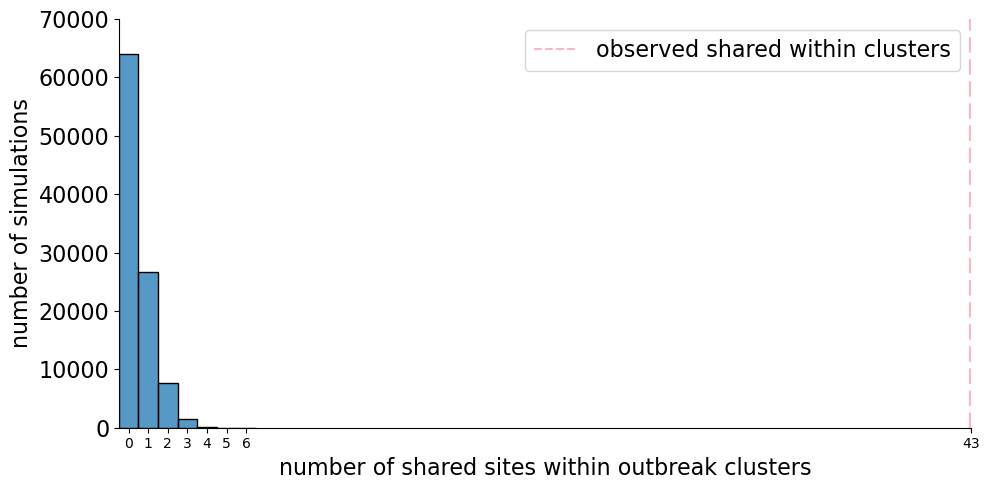

In [48]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from matplotlib.lines import Line2D

# # Set colors
# colors = {
#     "LBM": lbm_color,
#     "commercial": commercial_color
# }

# Set plot size
plt.figure(figsize=(10, 5))

# Create histogram
sns.histplot(
    data=df,
    x="full_genome",
    # hue="cluster",
    # bins=13,            # bins from -0.5 to 12.5 for integer binning
    # binrange=(-0.5, 12.5),
    bins=7,            # bins from -0.5 to 12.5 for integer binning
    binrange=(-0.5, 6.5),
    
    multiple="dodge",
    # palette=colors,
    edgecolor="black"
)

# # Add vertical lines at x=3 and x=9
plt.axvline(x=43, color='#FFB6C1', linestyle="--", linewidth=3)
# plt.axvline(x=0, color=clust2, linestyle="--", linewidth=1.6)
# plt.axvline(x=14, color=clust3, linestyle="--", linewidth=1.6)
# plt.axvline(x=13, color=clust4, linestyle="--", linewidth=1.6)
# plt.axvline(x=11, color=clust5, linestyle="--", linewidth=1.6)

# Set axes limits and ticks
plt.xlim(-0.5, 15.5)
plt.xticks(np.arange(0, 15, 1)) # show all integer ticks from 0 to 15
# plt.ylim(0, 100000)
plt.ylim(0, 70000)
# plt.yscale('log')


# Labels
plt.xlabel("number of shared sites within outbreak clusters", fontsize=16)
plt.ylabel("number of simulations", fontsize=16)

# Tick size
# plt.xticks(fontsize=16)
plt.yticks(fontsize=16)

plt.xticks(list(range(0, 7)) + [43])


# Legend
# plt.legend(fontsize=16)
legend_elements = [Line2D([0], [0], color='#FFB6C1', ls='--', label='observed shared within clusters')]
plt.legend(handles=legend_elements, loc='upper right', fontsize=16)

# Remove grid
sns.despine()

# Tight layout and save
plt.tight_layout()

filename = '../output_plots/'+todays_date+'_shared-sites-perm-aa-withinclust-grouped.png'
plt.savefig(filename, format='png')

# Show plot
plt.show()


NameError: name 'ax' is not defined

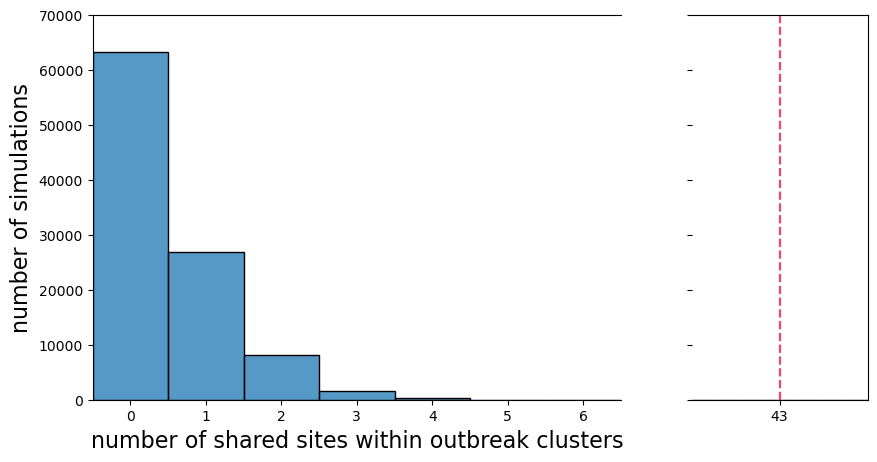

In [111]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from matplotlib.lines import Line2D

# Create two side-by-side axes
fig, (ax1, ax2) = plt.subplots(
    1, 2, sharey=True, figsize=(10, 5),
    gridspec_kw={'width_ratios': [3, 1]}
)

# ---- LEFT PLOT (main distribution: 0–6) ----
sns.histplot(
    data=df,
    x="full_genome",
    bins=7,
    binrange=(-0.5, 6.5),
    edgecolor="black",
    ax=ax1
)

ax1.set_xlim(-0.5, 6.5)
ax1.set_xticks(range(0, 7))

# ---- RIGHT PLOT (outlier region around 43) ----
sns.histplot(
    data=df,
    x="full_genome",
    bins=7,
    binrange=(40, 46),
    edgecolor="black",
    ax=ax2
)

ax2.set_xlim(40, 46)
ax2.set_xticks([43])

# ---- Vertical line (observed value) ----
ax2.axvline(x=43, color=clust1, linestyle="--", linewidth=1.6)

# ---- Styling ----
ax1.set_xlabel("number of shared sites within outbreak clusters", fontsize=16)
ax1.set_ylabel("number of simulations", fontsize=16)

ax2.set_xlabel("")

ax1.set_ylim(0, 70000)

# # Remove spines between plots
# ax1.spines['right'].set_visible(False)
# ax2.spines['left'].set_visible(False)

ax1.spines['right'].set_visible(False)
ax2.spines['left'].set_visible(False)
ax.yaxis.tick_left()
ax1.tick_params(labelright='off')
ax2.yaxis.tick_right()

# # Diagonal break marks
# d = .015
# kwargs = dict(transform=ax1.transAxes, color='k', clip_on=False)
# ax1.plot((1-d, 1+d), (-d, +d), **kwargs)
# ax1.plot((1-d, 1+d), (1-d, 1+d), **kwargs)

# kwargs.update(transform=ax2.transAxes)
# ax2.plot((-d, +d), (-d, +d), **kwargs)
# ax2.plot((-d, +d), (1-d, 1+d), **kwargs)

# Legend
legend_elements = [
    Line2D([0], [0], color='#C15D1A', ls='--',
           label='observed shared within clusters')
]
ax1.legend(handles=legend_elements, loc='center right', fontsize=12)

sns.despine()

plt.tight_layout()
plt.show()

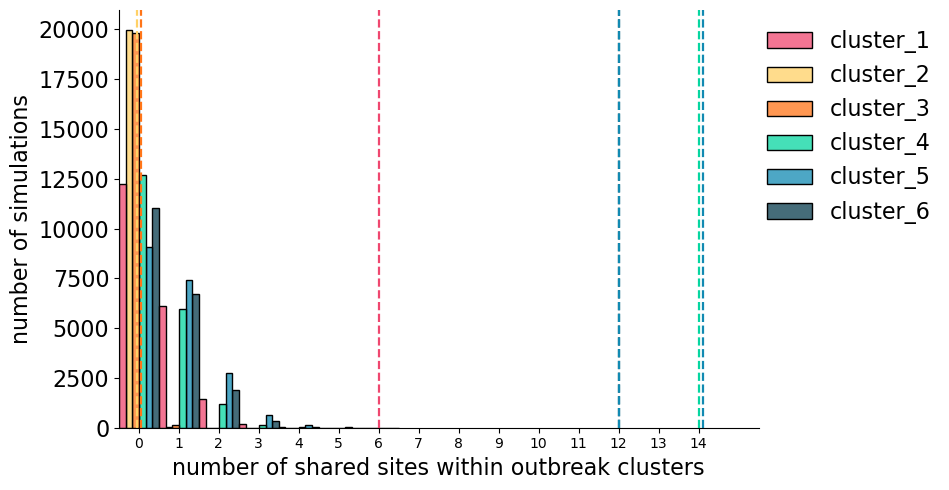

In [30]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# define colors 
clust1 = "#ef476f" #bubblegumpink
clust2 = "#ffd166" #royalgold
clust3 = "#FF7518" #emerald
clust4 = "#06d6a0" #oceanblue
clust5 = "#118ab2" #darkteal
clust6 = "#073b4c" #MAKE ORANGE


# # Set colors
colors = {
    "cluster_1": clust1,
    "cluster_2": clust2,
    "cluster_3": clust3,
    "cluster_4": clust4,
    "cluster_5": clust5,
    "cluster_6": clust6

}

# Set plot size
plt.figure(figsize=(10, 5))

# Create histogram
ax = sns.histplot(
        data=df,
        x="full_genome",
        hue="cluster",
        palette=colors,
        # bins=13,            # bins from -0.5 to 12.5 for integer binning
        # binrange=(-0.5, 12.5),
        bins=7,            # bins from -0.5 to 12.5 for integer binning
        binrange=(-0.5, 6.5),
        multiple="dodge",
        # palette=colors,
        edgecolor="black"
    )

# # Add vertical lines at x=3 and x=9 ####update for 6 clusters!!
plt.axvline(x=6, color=clust1, linestyle="--", linewidth=1.6)
plt.axvline(x=-.05, color=clust2, linestyle="--", linewidth=1.6)
plt.axvline(x=0.05, color=clust3, linestyle="--", linewidth=1.6)
plt.axvline(x=14, color=clust4, linestyle="--", linewidth=1.6)
plt.axvline(x=14.1, color=clust5, linestyle="--", linewidth=1.6)
plt.axvline(x=12, color=clust6, linestyle="--", linewidth=1.6)


plt.axvline(x=12, color=clust5, linestyle="--", linewidth=1.6)



# Set axes limits and ticks
plt.xlim(-0.5, 15.5)
plt.xticks(np.arange(0, 15, 1)) # show all integer ticks from 0 to 15
# plt.ylim(0, 100000)
# plt.ylim(0, 100000)
# plt.yscale('log')

# Labels
plt.xlabel("number of shared sites within outbreak clusters", fontsize=16)
plt.ylabel("number of simulations", fontsize=16)

# Tick size
# plt.xticks(fontsize=16)
plt.yticks(fontsize=16)

# plt.xticks(list(range(0, 21)) + [28, 33])


#Legend
# plt.legend(fontsize=16, loc="best")
sns.move_legend(ax, loc="upper right", bbox_to_anchor=(1.3, 1), fontsize=16, frameon=False, title=None)

# Remove grid
sns.despine()

# Tight layout and save
plt.tight_layout()

filename = '../output_plots/'+todays_date+'_shared-sites-perm-aa-clusters.png'
plt.savefig(filename, format='png')

# Show plot
plt.show()


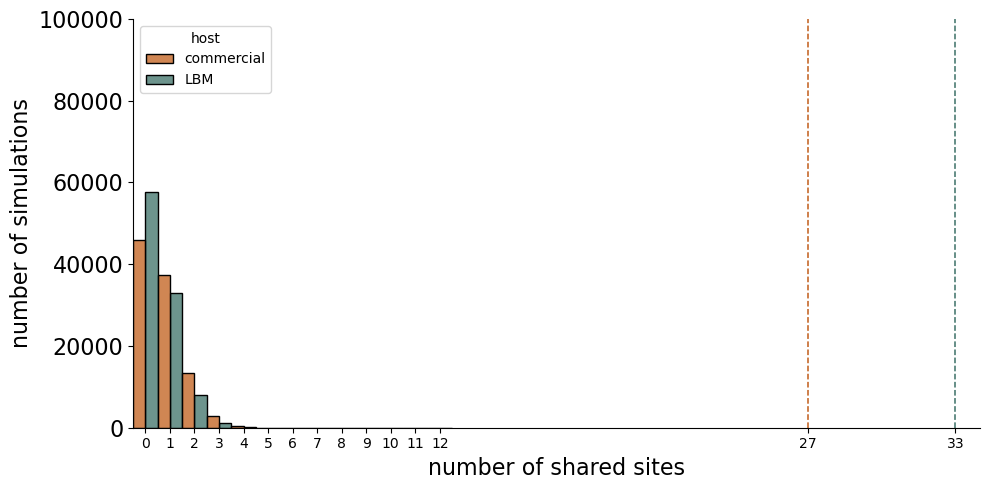

In [154]:
# import matplotlib.pyplot as plt
# import seaborn as sns
# import pandas as pd
# import numpy as np

# commercial_color = "#C15D1A"
# lbm_color = "#3C7067"

# # Set colors
# colors = {
#     "LBM": lbm_color,
#     "commercial": commercial_color
# }

# # Set plot size
# plt.figure(figsize=(10, 5))

# # Create histogram
# sns.histplot(
#     data=df,
#     x="HA",
#     hue="host",
#     bins=13,            # bins from -0.5 to 12.5 for integer binning
#     binrange=(-0.5, 12.5),
#     multiple="dodge",
#     palette=colors,
#     edgecolor="black"
# )

# # Add vertical lines at x=3 and x=9
# plt.axvline(x=33, color=lbm_color, linestyle="--", linewidth=1.1)
# plt.axvline(x=27, color=commercial_color, linestyle="--", linewidth=1.1)

# # Set axes limits and ticks
# plt.xlim(-0.5, 33)
# plt.xticks(np.arange(0, 35, 1)) # show all integer ticks from 0 to 15
# # plt.ylim(0, 100000)
# plt.ylim(0, 100000)


# # Labels
# plt.xlabel("number of shared sites", fontsize=16)
# plt.ylabel("number of simulations", fontsize=16)

# # Tick size
# # plt.xticks(fontsize=16)
# plt.yticks(fontsize=16)

# plt.xticks(list(range(0, 13)) + [27, 33])

# # Legend
# # plt.legend(fontsize=16)

# # Remove grid
# sns.despine()

# # Tight layout and save
# plt.tight_layout()
# # plt.savefig("../../seq/analysis/figures/2026-02-06_shared_sites_perm_aa_test.pdf", format='pdf')

# # Show plot
# plt.show()


In [142]:
# ##merging this all together to see how many SNPs should be shared by chance between all samples??
# # num_sims = 100000
# num_sims = 100000

# all_data = simulate_shared_sites(SNPs_all, aa_coverages, num_sims)

In [143]:
# # convert to dataframe
# df_all = pd.DataFrame(all_data, columns=all_data.keys())
# df_all = df_all.reset_index()
# df_all["full_genome"] = df_all['PB2'] + df_all['PB1'] + df_all['PA'] + df_all['HA'] + df_all['NP'] + df_all['NA'] + df_all['M1'] + df_all['M2'] + df_all['NS1'] + df_all['NEP']
# df_all["host"] = "commercial"

# df_all.head()

,index,PB2,PB1,PA,HA,NP,NA,M1,M2,NS1,NEP,full_genome,host
0,0,2,1,1,3,3,1,0,0,1,0,12,commercial
1,1,3,1,2,0,3,3,0,0,0,0,12,commercial
2,2,5,1,5,1,5,5,0,0,1,0,23,commercial
3,3,3,5,1,3,3,3,0,0,3,0,21,commercial
4,4,2,4,2,1,6,3,0,0,0,0,18,commercial


In [144]:
# df_all['full_genome'].value_counts()

full_genome
20    9757
19    9677
21    9437
18    8884
22    8580
17    7685
23    7338
16    6038
24    5988
25    4665
15    4487
26    3448
14    3085
27    2458
13    1994
28    1599
12    1176
29    1062
11     661
30     598
31     382
10     289
32     234
9      161
33     116
8       72
34      52
35      27
7       17
36      16
37      10
6        4
38       2
41       1
Name: count, dtype: int64

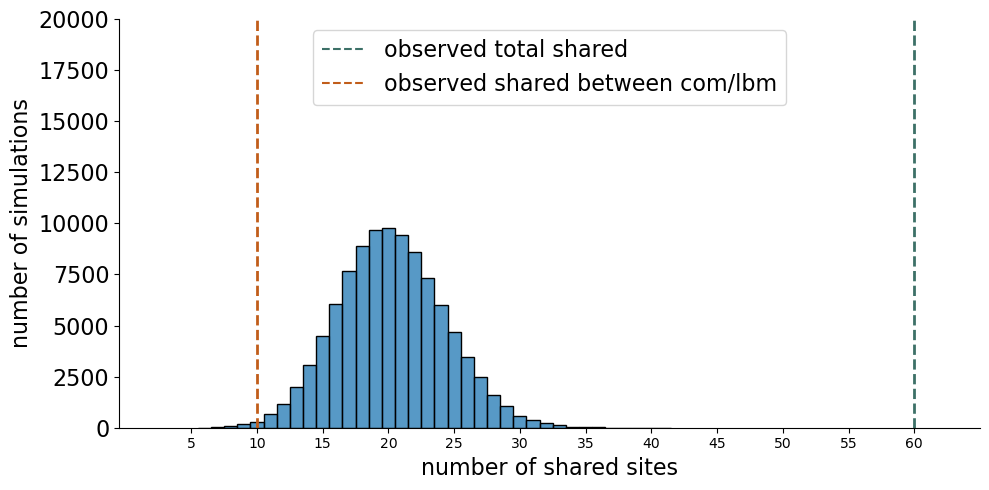

In [180]:
# import matplotlib.pyplot as plt
# import seaborn as sns
# import pandas as pd
# import numpy as np
# from matplotlib.lines import Line2D

# commercial_color = "#C15D1A"
# lbm_color = "#3C7067"
# # # Set colors
# # colors = {
# #     "LBM": lbm_color,
# #     "commercial": commercial_color
# # }

# # Set plot size
# plt.figure(figsize=(10, 5))

# # Create histogram
# sns.histplot(
#     data=df_all,
#     x="full_genome",
#     # hue="host",
#     bins=36,            # bins from -0.5 to 12.5 for integer binning
#     binrange=(5.5, 41.5),
#     multiple="dodge",
#     # palette=colors,
#     edgecolor="black"
# )

# # Add vertical lines at x=3 and x=9
# plt.axvline(x=60, color=lbm_color, linestyle="--", linewidth=2, label="Observed = 60"
# )
# plt.axvline(x=10, color=commercial_color, linestyle="--", linewidth=2)

# # Set axes limits and ticks
# plt.xlim(-0.5, 65)
# # plt.xticks(np.arange(0, 41, 2)) # show all integer ticks from 0 to 15
# # plt.ylim(0, 100000)
# plt.ylim(0, 20000)


# # Labels
# plt.xlabel("number of shared sites", fontsize=16)
# plt.ylabel("number of simulations", fontsize=16)

# # Tick size
# # plt.xticks(fontsize=16)
# plt.yticks(fontsize=16)

# # plt.xticks(list(range(0, 41)) + [60])
# plt.xticks(np.arange(5, 65, 5)) # show all integer ticks from 0 to 15

# # Legend
# # plt.legend(fontsize=16)

# legend_elements = [Line2D([0], [0], color='#3C7067', ls='--', label='observed total shared'),
#                    Line2D([0], [0], color='#C15D1A', ls='--', label='observed shared between com/lbm')]
# plt.legend(handles=legend_elements, loc='upper center', fontsize=16)

# # Remove grid
# sns.despine()

# # Tight layout and save
# plt.tight_layout()
# plt.savefig("../../seq/analysis/figures/2026-02-27_shared_sites_perm_aa_test-allcomgrouped.pdf", format='pdf')

# # Show plot
# plt.show()


In [186]:
# # Total polymorphic sites across all samples & genes
# sum([sum(genes.values()) for genes in SNPs_lbm2.values()])
# # sum([sum(genes.values()) for genes in SNPs_lbm2.values()])


187

In [31]:
import random
from collections import Counter

def simulate_between_multiple_groups(
        polymorphism_groups,   # dict: group_name -> polymorphisms
        coverage_groups,       # dict: group_name -> coverage
        num_sims):

    genes = ["PB2", "PB1", "PA", "HA", "NP", "NA", 
             "M1", "M2", "NS1", "NEP"]

    iteration_results = {gene: [] for gene in genes}

    for sim in range(num_sims):

        group_results = {}

        # ---- Simulate each group ----
        for group_name in polymorphism_groups:

            polymorphisms = polymorphism_groups[group_name]
            coverages = coverage_groups[group_name]

            results = {gene: [] for gene in genes}

            for sample in polymorphisms:
                for gene in polymorphisms[sample]:

                    num_possible_sites = range(
                        coverages[sample][gene]
                    )
                    num_sites_to_draw = polymorphisms[sample][gene]

                    random_draw = random.sample(
                        num_possible_sites,
                        num_sites_to_draw
                    )

                    results[gene].extend(random_draw)

            group_results[group_name] = results

        # ---- Count shared sites (>=2 groups) ----
        for gene in genes:

            # unique sites per group
            all_unique_sets = [
                set(group_results[group][gene])
                for group in group_results
            ]

            # count occurrences across groups
            counts = Counter(site for s in all_unique_sets for site in s)

            # # ---- DEBUG PRINT (REMOVE OR COMMENT FOR FULL RUNS) ----
            if sim < 3:  # only print first few sims to avoid huge output
            
                print(f"\nSimulation {sim}, Gene {gene}")
            
                for i, group_name in enumerate(group_results):
                    print(f"{group_name}:", all_unique_sets[i])
            
                print("Counts (site -> #groups):")
                print(dict(counts))
            
                shared_2plus_sites = [site for site, c in counts.items() if c >= 2]
            
                print("Shared (>=2 groups):", shared_2plus_sites)
                print("Shared count:", len(shared_2plus_sites))
            
                print("-" * 60)

            #     ########################

            # sites present in 2+ groups
            shared_2plus = sum(v >= 2 for v in counts.values())

            iteration_results[gene].append(shared_2plus)

    return iteration_results

In [36]:
num_sims = 100000

polymorphism_groups = {
    "cluster_1": SNPs_by_cluster2["cluster_1"],
    "cluster_2": SNPs_by_cluster2["cluster_2"],
    "cluster_3": SNPs_by_cluster2["cluster_3"],
    "cluster_4": SNPs_by_cluster2["cluster_4"],
    "cluster_5": SNPs_by_cluster2["cluster_5"],
    "cluster_6": SNPs_by_cluster2["cluster_6"],

}

coverage_groups = {
    "cluster_1": aa_coverages_clust1,
    "cluster_2": aa_coverages_clust2,
    "cluster_3": aa_coverages_clust3,
    "cluster_4": aa_coverages_clust4,
    "cluster_5": aa_coverages_clust5,
    "cluster_6": aa_coverages_clust6,

}

multi_group_data = simulate_between_multiple_groups(
    polymorphism_groups,
    coverage_groups,
    num_sims
)


Simulation 0, Gene PB2
cluster_1: {97, 169, 362, 143, 657, 498, 725, 158, 573, 414}
cluster_2: {34, 214}
cluster_3: {28}
cluster_4: {1, 226, 712, 299, 363, 109, 304, 657, 21, 250, 123, 188, 381}
cluster_5: {641, 744, 11, 557, 750, 718, 400, 625, 273, 444}
cluster_6: {513, 675, 637, 6, 71, 7, 589, 18, 754, 757, 89, 442, 29}
Counts (site -> #groups):
{97: 1, 169: 1, 362: 1, 143: 1, 657: 2, 498: 1, 725: 1, 158: 1, 573: 1, 414: 1, 34: 1, 214: 1, 28: 1, 1: 1, 226: 1, 712: 1, 299: 1, 363: 1, 109: 1, 304: 1, 21: 1, 250: 1, 123: 1, 188: 1, 381: 1, 641: 1, 744: 1, 11: 1, 557: 1, 750: 1, 718: 1, 400: 1, 625: 1, 273: 1, 444: 1, 513: 1, 675: 1, 637: 1, 6: 1, 71: 1, 7: 1, 589: 1, 18: 1, 754: 1, 757: 1, 89: 1, 442: 1, 29: 1}
Shared (>=2 groups): [657]
Shared count: 1
------------------------------------------------------------

Simulation 0, Gene PB1
cluster_1: {353, 513, 163, 453, 141, 399, 656, 305, 503, 347, 383}
cluster_2: {53}
cluster_3: {448, 499, 246}
cluster_4: {193, 104, 521, 201, 617, 13,

In [37]:
# convert to dataframe
df_bw = pd.DataFrame(multi_group_data, columns=multi_group_data.keys())
df_bw = df_bw.reset_index()
df_bw["full_genome"] = df_bw['PB2'] + df_bw['PB1'] + df_bw['PA'] + df_bw['HA'] + df_bw['NP'] + df_bw['NA'] + df_bw['M1'] + df_bw['M2'] + df_bw['NS1'] + df_bw['NEP']
# df_bw["host"] = "commercial"

df_bw.head()

,index,PB2,PB1,PA,HA,NP,NA,M1,M2,NS1,NEP,full_genome
0,0,1,2,0,1,4,1,0,0,1,0,10
1,1,1,2,2,0,2,1,0,0,0,0,8
2,2,4,1,2,1,1,0,0,0,0,0,9
3,3,0,2,0,0,0,1,0,0,1,0,4
4,4,1,0,1,2,1,1,0,0,0,0,6


In [38]:
df_bw['full_genome'].value_counts()

full_genome
8     14631
7     13715
9     13569
6     11402
10    11270
11     8332
5      7842
12     5306
4      4428
13     3340
3      1945
14     1770
15      868
2       658
16      444
17      187
1       147
18       85
19       26
0        19
20        8
22        4
21        4
Name: count, dtype: int64

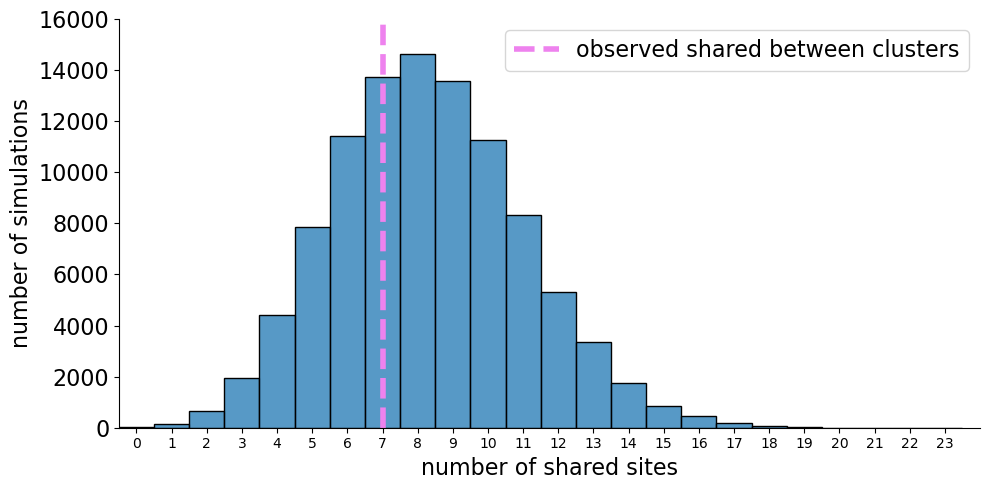

In [43]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from matplotlib.lines import Line2D

commercial_color = "#C15D1A"
lbm_color = "#3C7067"
# # Set colors
# colors = {
#     "LBM": lbm_color,
#     "commercial": commercial_color
# }

# Set plot size
plt.figure(figsize=(10, 5))

# Create histogram
sns.histplot(
    data=df_bw,
    x="full_genome",
    # hue="host",
    bins=24,            # bins from -0.5 to 12.5 for integer binning
    binrange=(-0.5, 23.5),
    multiple="dodge",
    # palette=colors,
    edgecolor="black"
)

# Add vertical lines at x=3 and x=9
# plt.axvline(x=60, color=lbm_color, linestyle="--", linewidth=2, label="Observed = 60"
# )
plt.axvline(x=7, color='#EE82EE', linestyle="--", linewidth=4)

# Set axes limits and ticks
plt.xlim(-0.5, 24)
# plt.xticks(np.arange(0, 41, 2)) # show all integer ticks from 0 to 15
# plt.ylim(0, 100000)
plt.ylim(0, 16000)


# Labels
plt.xlabel("number of shared sites", fontsize=16)
plt.ylabel("number of simulations", fontsize=16)

# Tick size
# plt.xticks(fontsize=16)
plt.yticks(fontsize=16)

# plt.xticks(list(range(0, 41)) + [60])
plt.xticks(np.arange(0, 24, 1)) # show all integer ticks from 0 to 15

# Legend
# plt.legend(fontsize=16)

# legend_elements = [Line2D([0], [0], color='#3C7067', ls='--', label='observed total shared'),
#                    Line2D([0], [0], color='#C15D1A', ls='--', label='observed shared between com/lbm')]
legend_elements = [Line2D([0], [0], color='#EE82EE', ls='--', lw=4, label='observed shared between clusters')]
plt.legend(handles=legend_elements, loc='upper right', fontsize=16)

# Remove grid
sns.despine()

# Tight layout and save
plt.tight_layout()

filename='../output_plots/'+todays_date+'_shared-sites-perm-aa-bw-cluster.png'
plt.savefig(filename, format='png')

# Show plot
plt.show()


In [206]:
# ##what i really want to know is the number of expected shared BETWEEN these datasets (lbm and commercial), so here is an amendeded version of the
# ##simulation function:


# import random
# from collections import Counter

# def simulate_between_dataset_shared_sites(
#         polymorphisms_A, num_sites_A,
#         polymorphisms_B, num_sites_B,
#         num_sims):

#     genes = ["PB2", "PB1", "PA", "HA", "NP", "NA", 
#              "M1", "M2", "NS1", "NEP"]
    
#     iteration_results = {gene: [] for gene in genes}

#     for sim in range(num_sims):

#         results_A = {gene: [] for gene in genes}
#         results_B = {gene: [] for gene in genes}

#         # ---- Dataset A draws ----
#         for sample in polymorphisms_A:
#             for gene in polymorphisms_A[sample]:

#                 num_possible_sites = range(
#                     num_sites_A[sample][gene]
#                 )
#                 num_sites_to_draw = polymorphisms_A[sample][gene]

#                 random_draw = random.sample(
#                     num_possible_sites,
#                     num_sites_to_draw
#                 )

#                 results_A[gene].extend(random_draw)

#         # ---- Dataset B draws ----
#         for sample in polymorphisms_B:
#             for gene in polymorphisms_B[sample]:

#                 num_possible_sites = range(
#                     num_sites_B[sample][gene]
#                 )
#                 num_sites_to_draw = polymorphisms_B[sample][gene]

#                 random_draw = random.sample(
#                     num_possible_sites,
#                     num_sites_to_draw
#                 )

#                 results_B[gene].extend(random_draw)

#         # ---- Count overlap per gene ----
#         for gene in genes:

#             unique_A = set(results_A[gene])
#             unique_B = set(results_B[gene])


# ##putting this here just to check that it's working for a mini sim
#             # print(f"Simulation {sim}, Gene {gene}")
#             # print("Unique A:", unique_A)
#             # print("Unique B:", unique_B)
#             # print("Shared:", unique_A & unique_B)
#             # print("-" * 40)
# #######
#             shared = len(unique_A & unique_B)

#             iteration_results[gene].append(shared)

#     return iteration_results

In [207]:
# num_sims = 100000


# between_data = simulate_between_dataset_shared_sites(
#     SNPs_commercial2, aa_coverages_commercial,
#     SNPs_lbm2, aa_coverages_lbm,
#     num_sims
# )


Simulation 0, Gene PB2
Unique A: {385, 644, 645, 11, 18, 402, 149, 156, 541, 32, 289, 34, 288, 679, 298, 683, 171, 685, 49, 50, 690, 54, 56, 187, 573, 318, 580, 709, 69, 711, 200, 202, 715, 718, 83, 733, 482, 484, 485, 231, 743, 502, 122, 379, 124, 382}
Unique B: {257, 260, 133, 395, 268, 398, 655, 408, 33, 293, 42, 303, 701, 319, 200, 713, 328, 329, 718, 209, 82, 340, 597, 87, 88, 351, 356, 101, 486, 232, 106, 238, 114, 246, 251, 381}
Shared: {200, 718}
----------------------------------------
Simulation 0, Gene PB1
Unique A: {132, 519, 265, 274, 407, 409, 667, 672, 547, 685, 173, 175, 48, 691, 54, 572, 452, 325, 70, 328, 588, 204, 336, 345, 604, 349, 93, 351, 363, 748, 110, 112, 753, 502, 379, 124}
Unique B: {3, 264, 138, 532, 410, 159, 160, 31, 671, 419, 298, 45, 688, 58, 454, 712, 331, 590, 335, 464, 337, 338, 475, 92, 96, 608, 504, 621, 240, 374, 375, 632, 637, 127}
Shared: set()
----------------------------------------
Simulation 0, Gene PA
Unique A: {0, 256, 643, 646, 524, 400, 

In [199]:
# # convert to dataframe
# df_bw = pd.DataFrame(between_data, columns=between_data.keys())
# df_bw = df_bw.reset_index()
# df_bw["full_genome"] = df_bw['PB2'] + df_bw['PB1'] + df_bw['PA'] + df_bw['HA'] + df_bw['NP'] + df_bw['NA'] + df_bw['M1'] + df_bw['M2'] + df_bw['NS1'] + df_bw['NEP']
# # df_bw["host"] = "commercial"

# df_bw.head()

,index,PB2,PB1,PA,HA,NP,NA,M1,M2,NS1,NEP,full_genome
0,0,2,0,1,1,0,2,0,0,0,0,6
1,1,1,4,0,0,2,1,0,0,0,0,8
2,2,0,2,2,2,1,3,0,0,1,0,11
3,3,2,2,3,1,4,1,0,0,1,0,14
4,4,4,2,0,2,4,2,0,0,1,0,15


In [200]:
# df_bw['full_genome'].value_counts()

full_genome
10    12939
9     12532
11    12415
8     10867
12    10437
7      8198
13     8112
14     5663
6      5392
15     3756
5      2995
16     2237
4      1384
17     1248
18      664
3       467
19      318
20      142
2       113
21       69
22       19
1        18
23        8
0         4
24        2
25        1
Name: count, dtype: int64

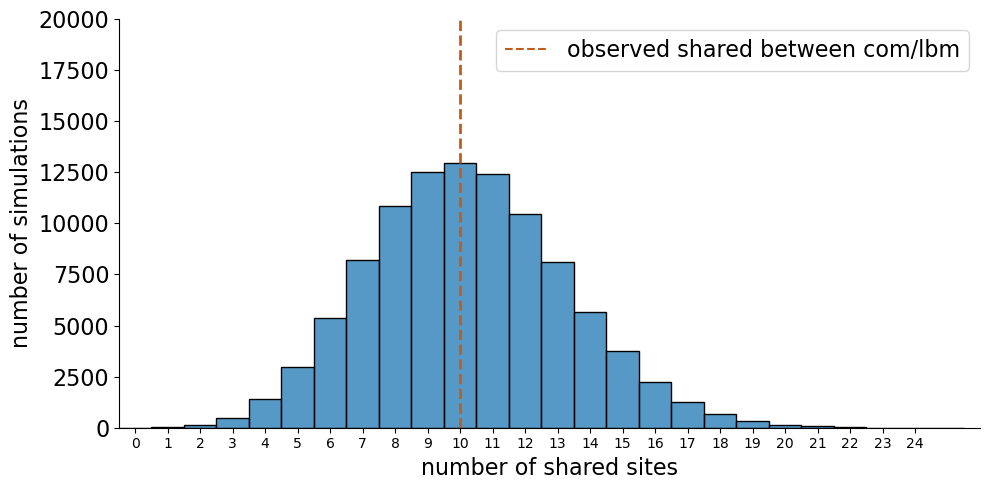

In [202]:
# import matplotlib.pyplot as plt
# import seaborn as sns
# import pandas as pd
# import numpy as np
# from matplotlib.lines import Line2D

# commercial_color = "#C15D1A"
# lbm_color = "#3C7067"
# # # Set colors
# # colors = {
# #     "LBM": lbm_color,
# #     "commercial": commercial_color
# # }

# # Set plot size
# plt.figure(figsize=(10, 5))

# # Create histogram
# sns.histplot(
#     data=df_bw,
#     x="full_genome",
#     # hue="host",
#     bins=26,            # bins from -0.5 to 12.5 for integer binning
#     binrange=(-0.5, 25.5),
#     multiple="dodge",
#     # palette=colors,
#     edgecolor="black"
# )

# # Add vertical lines at x=3 and x=9
# # plt.axvline(x=60, color=lbm_color, linestyle="--", linewidth=2, label="Observed = 60"
# # )
# plt.axvline(x=10, color=commercial_color, linestyle="--", linewidth=2)

# # Set axes limits and ticks
# plt.xlim(-0.5, 26)
# # plt.xticks(np.arange(0, 41, 2)) # show all integer ticks from 0 to 15
# # plt.ylim(0, 100000)
# plt.ylim(0, 20000)


# # Labels
# plt.xlabel("number of shared sites", fontsize=16)
# plt.ylabel("number of simulations", fontsize=16)

# # Tick size
# # plt.xticks(fontsize=16)
# plt.yticks(fontsize=16)

# # plt.xticks(list(range(0, 41)) + [60])
# plt.xticks(np.arange(0, 25, 1)) # show all integer ticks from 0 to 15

# # Legend
# # plt.legend(fontsize=16)

# # legend_elements = [Line2D([0], [0], color='#3C7067', ls='--', label='observed total shared'),
# #                    Line2D([0], [0], color='#C15D1A', ls='--', label='observed shared between com/lbm')]
# legend_elements = [Line2D([0], [0], color='#C15D1A', ls='--', label='observed shared between com/lbm')]
# plt.legend(handles=legend_elements, loc='upper right', fontsize=16)

# # Remove grid
# sns.despine()

# # Tight layout and save
# plt.tight_layout()
# plt.savefig("../../seq/analysis/figures/2026-03-03_shared_sites_perm_aa_test-bw-com-lbm.pdf", format='pdf')

# # Show plot
# plt.show()


## Results

Because this is simulation based, the actual numbers change each time, but the results stay similar from instance to instance. 

Basically, this tells us that out of 100,000 simulations of random mutations, the vast majority of the time, there will be between 2 and 6 sites that are shared by chance alone in humans, and 0 to 1 sites shared in birds. Some simulations result in at least 9 shared sites in humans, and very few simulations resulted in >= 3 shared sites in ducks.

human p-value: 0.01185
duck p-value:  0.00003

Both humans and ducks share more variation than expected by chance alone. 

## Step 5: Different percentages of genome mutatable

Although this first pass seems like a reasonable way to assess how many shared sites we would expect to see by chance alone, I think it would also be useful to rerun the simulation with a smaller fraction of sites available to mutate. The idea I have here is that the vast majority of codon changes will be so deleterious that you would never expect to observe them in nature. What our results could be showing us is not necessarily that the shared sites we are seeing are mostly driven by adaptation, but rather they reflect random mutations in the small subset of mutations that are actually tolerated for these genes to still produce a functional protein, regardless of host species. So I would like to try out a few different values of limiting the number of possible amino acid site substitutions in line with estimates from the literature. 

This paper estimates a lethal fraction of about 30%: https://www.ncbi.nlm.nih.gov/pmc/articles/PMC5003363/

This review suggests that most viruses have lethal fractions ranging between 20-40%: https://royalsocietypublishing.org/doi/10.1098/rstb.2010.0063

In [37]:
# # Assume that only some fraction of sites could actually have a mutation that you could observe 

# fraction_of_gene_mutation_tolerated = 0.7

# aa_coverages_human = {}
# aa_coverages_duck = {}

# for sample in coverage["human"]: 
#     aa_coverages_human[sample] = {}
#     for gene in coverage["human"][sample]: 
        
#         nuc_sites = coverage["human"][sample][gene]
#         aa_value = int(nuc_sites/(3 * (1/fraction_of_gene_mutation_tolerated)))
#         aa_coverages_human[sample][gene] = aa_value

# for sample in coverage["duck"]: 
#     aa_coverages_duck[sample] = {}
#     for gene in coverage["duck"][sample]: 
        
#         nuc_sites = coverage["duck"][sample][gene]
#         aa_value = int(nuc_sites/(3 * (1/fraction_of_gene_mutation_tolerated)))
#         aa_coverages_duck[sample][gene] = aa_value

# print(aa_coverages_human)

{'AJ4MBL723F512_A_CAMBODIA_V0401301_2011': {'PB2': 518, 'PB1': 513, 'PA': 494, 'HA': 224, 'NP': 329, 'NA': 301, 'M1': 166, 'M2': 60, 'NS1': 148, 'NEP': 72}, 'AJ4MBL718F513_A_CAMBODIA_V0417301_2011': {'PB2': 517, 'PB1': 523, 'PA': 496, 'HA': 333, 'NP': 339, 'NA': 301, 'M1': 165, 'M2': 60, 'NS1': 144, 'NEP': 71}, 'AJ4MBL720F513_A_Cambodia_W0112303_2012': {'PB2': 513, 'PB1': 521, 'PA': 498, 'HA': 338, 'NP': 337, 'NA': 300, 'M1': 167, 'M2': 61, 'NS1': 144, 'NEP': 71}, 'AJ4MBL720F514_A_Cambodia_X0125302_2013': {'PB2': 513, 'PB1': 518, 'PA': 497, 'HA': 155, 'NP': 338, 'NA': 303, 'M1': 166, 'M2': 62, 'NS1': 149, 'NEP': 75}, 'AA4KNL706F512_A_Cambodia_X0128304_2013': {'PB2': 518, 'PB1': 0, 'PA': 483, 'HA': 386, 'NP': 334, 'NA': 303, 'M1': 168, 'M2': 61, 'NS1': 151, 'NEP': 78}, 'AJ4MBL723F514_A_Cambodia_X0207301_2013': {'PB2': 516, 'PB1': 517, 'PA': 497, 'HA': 342, 'NP': 340, 'NA': 301, 'M1': 166, 'M2': 60, 'NS1': 142, 'NEP': 69}, 'AJ4MBL718F515_A_Cambodia_X0219301_2013': {'PB2': 518, 'PB1': 516

In [113]:
fraction_of_gene_mutation_tolerated = 0.6

aa_coverages = {}
genes_all = ["PB2", "PB1", "PA", "HA", "NP", "NA", "M1", "M2", "NS1", "NEP"]

for sample in df["sample"].unique():
    sample_dict = {}

    for gene in genes_all:
        if gene in coding_regions:
            coords = coding_regions[gene]

            # Calculate nucleotide length across all coding intervals
            nuc_length = 0
            for i in range(0, len(coords), 2):
                start = coords[i]
                stop = coords[i+1]
                nuc_length += abs(stop - start) + 1  # inclusive

            # Apply mutation-tolerated fraction
            adjusted_nuc_length = nuc_length * fraction_of_gene_mutation_tolerated

            # Convert to number of codons (amino acid sites)
            aa_sites = int(adjusted_nuc_length / 3)
            sample_dict[gene] = aa_sites
        else:
            sample_dict[gene] = 0  # No coordinates for this gene

    aa_coverages[sample] = sample_dict

# Optional: Separate into commercial vs. wild using your df
aa_coverages_commercial = {}
aa_coverages_wild = {}

for sample in aa_coverages:
    status = df[df["sample"] == sample]["domestic_status"].iloc[0]  # assumes consistent status per sample

    if status == "commercial":
        aa_coverages_commercial[sample] = aa_coverages[sample]
    elif status == "wild":
        aa_coverages_wild[sample] = aa_coverages[sample]

# Final outputs
print("Commercial:")
print(aa_coverages_commercial)

print("\nWild:")
print(aa_coverages_wild)


Commercial:
{'cb_com1': {'PB2': 456, 'PB1': 454, 'PA': 430, 'HA': 340, 'NP': 299, 'NA': 282, 'M1': 151, 'M2': 196, 'NS1': 138, 'NEP': 167}, 'cb_com2': {'PB2': 456, 'PB1': 454, 'PA': 430, 'HA': 340, 'NP': 299, 'NA': 282, 'M1': 151, 'M2': 196, 'NS1': 138, 'NEP': 167}, 'cb_com3': {'PB2': 456, 'PB1': 454, 'PA': 430, 'HA': 340, 'NP': 299, 'NA': 282, 'M1': 151, 'M2': 196, 'NS1': 138, 'NEP': 167}, 'cb_com4': {'PB2': 456, 'PB1': 454, 'PA': 430, 'HA': 340, 'NP': 299, 'NA': 282, 'M1': 151, 'M2': 196, 'NS1': 138, 'NEP': 167}, 'g_com1': {'PB2': 456, 'PB1': 454, 'PA': 430, 'HA': 340, 'NP': 299, 'NA': 282, 'M1': 151, 'M2': 196, 'NS1': 138, 'NEP': 167}, 'g_com2': {'PB2': 456, 'PB1': 454, 'PA': 430, 'HA': 340, 'NP': 299, 'NA': 282, 'M1': 151, 'M2': 196, 'NS1': 138, 'NEP': 167}, 'kc_com1': {'PB2': 456, 'PB1': 454, 'PA': 430, 'HA': 340, 'NP': 299, 'NA': 282, 'M1': 151, 'M2': 196, 'NS1': 138, 'NEP': 167}, 'kc_com2': {'PB2': 456, 'PB1': 454, 'PA': 430, 'HA': 340, 'NP': 299, 'NA': 282, 'M1': 151, 'M2': 196

In [114]:
num_sims = 100000


comm_data2 = simulate_shared_sites(SNPs_commercial2, aa_coverages_commercial, num_sims)
wild_data2 = simulate_shared_sites(SNPs_wild2, aa_coverages_wild, num_sims)

In [115]:
# convert to dataframe
df_comm2 = pd.DataFrame(comm_data2, columns=comm_data2.keys())
df_comm2 = df_comm2.reset_index()
df_comm2["full_genome"] = df_comm2['PB2'] + df_comm2['PB1'] + df_comm2['PA'] + df_comm2['HA'] + df_comm2['NP'] + df_comm2['NA'] + df_comm2['M1'] + df_comm2['M2'] + df_comm2['NS1'] + df_comm2['NEP']
df_comm2["host"] = "commercial"

df_wild2 = pd.DataFrame(wild_data2, columns=wild_data2.keys())
df_wild2 = df_wild2.reset_index()
df_wild2["full_genome"] = df_wild2['PB2'] + df_wild2['PB1'] + df_wild2['PA'] + df_wild2['HA'] + df_wild2['NP'] + df_wild2['NA'] + df_wild2['M1'] + df_wild2['M2'] + df_wild2['NS1'] + df_wild2['NEP']
df_wild2["host"] = "wild"

df2 = pd.concat([df_comm2, df_wild2])
df2.head()

,index,PB2,PB1,PA,HA,NP,NA,M1,M2,NS1,NEP,full_genome,host
0,0,0,1,2,1,0,0,0,0,0,0,4,commercial
1,1,1,0,1,0,0,0,0,0,0,0,2,commercial
2,2,0,1,4,0,0,0,0,0,0,0,5,commercial
3,3,0,0,2,0,0,0,0,0,0,0,2,commercial
4,4,1,1,3,0,0,0,0,0,0,0,5,commercial


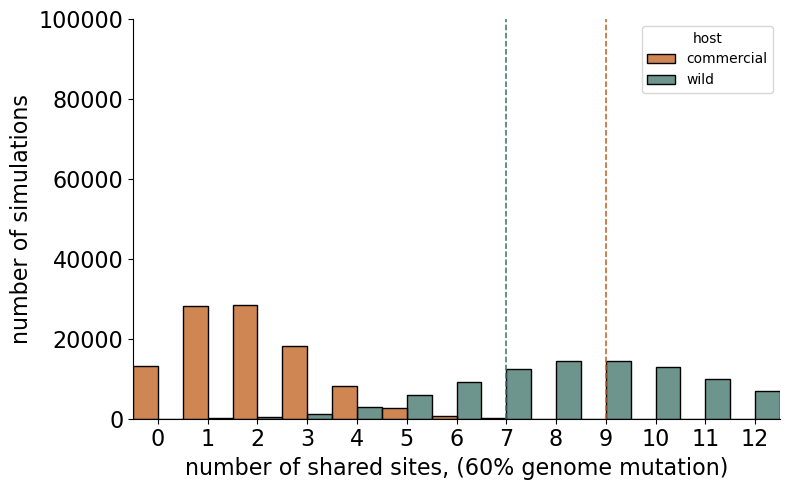

In [117]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# Set colors
colors = {
    "wild": wild_color,
    "commercial": commercial_color
}

# Set plot size
plt.figure(figsize=(8, 5))

# Create histogram
sns.histplot(
    data=df2,
    x="full_genome",
    hue="host",
    bins=13,            # bins from -0.5 to 12.5 for integer binning
    binrange=(-0.5, 12.5),
    multiple="dodge",
    palette=colors,
    edgecolor="black"
)

# Add vertical lines at x=3 and x=9
plt.axvline(x=7, color=wild_color, linestyle="--", linewidth=1.1)
plt.axvline(x=9, color=commercial_color, linestyle="--", linewidth=1.1)

# Set axes limits and ticks
plt.xlim(-0.5, 12.5)
plt.xticks(np.arange(0, 13, 1)) # show all integer ticks from 0 to 15
plt.ylim(0, 100000)

# Labels
plt.xlabel("number of shared sites, (60% genome mutation)", fontsize=16)
plt.ylabel("number of simulations", fontsize=16)

# Tick size
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)

# Legend
# plt.legend(fontsize=16)

# Remove grid
sns.despine()

# Tight layout and save
plt.tight_layout()
plt.savefig("../seq/analysis/figures/2025-08-05_shared_sites_perm_aa_test_60pct.pdf", format='pdf')

# Show plot
plt.show()


In [118]:
df_comm2 = df2[df2['host'] == 'commercial']
pd.to_numeric(df_comm2['full_genome'])
df_comm2[df_comm2['full_genome'] >= 9.0].count()

index          3
PB2            3
PB1            3
PA             3
HA             3
NP             3
NA             3
M1             3
M2             3
NS1            3
NEP            3
full_genome    3
host           3
dtype: int64

In [119]:
df_wild2 = df2[df2['host'] == 'wild']
pd.to_numeric(df_wild2['full_genome'])
df_wild2[df_wild2['full_genome'] >= 7.0].count()

index          80254
PB2            80254
PB1            80254
PA             80254
HA             80254
NP             80254
NA             80254
M1             80254
M2             80254
NS1            80254
NEP            80254
full_genome    80254
host           80254
dtype: int64

## Results:
**70% of the genome can tolerate a mutation:**

1 out of 100,000 simulations had at least 9 sites shared in commerical samples

65,712 simulations had at least 7 sites shared in wild samples 

**60% of the genome can tolerate a mutation:**

3 out of 100,000 simulations had at least 9 sites shared in humans: p = 0.168

80254 simulations had at least 7 shared sites in ducks: p = 0.00021